# Credit Scoring and Risk Prediction System using Machine Learning

## CodeAlpha Machine Learning Internship Project

##Building an intelligent credit scoring model using machine learning to assess customer credit risk based on demographic, financial, and credit history data.

# Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Step 2: Load Dataset

In [14]:
application = pd.read_csv("/content/application_record.csv")
credit = pd.read_csv("/content/credit_record.csv")

print("Application Shape:", application.shape)
print("Credit Shape:", credit.shape)

Application Shape: (438557, 18)
Credit Shape: (1048575, 3)


# Step 3: Display First Rows

In [15]:
application.head()
credit.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


# Step 4: Check Missing Values

In [16]:
application.isnull().sum()

,0
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0


# Step 5: Handle Missing Values

In [17]:
application["OCCUPATION_TYPE"].fillna( application["OCCUPATION_TYPE"].mode()[0], inplace=True )

/tmp/ipykernel_727/3949632436.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  application["OCCUPATION_TYPE"].fillna( application["OCCUPATION_TYPE"].mode()[0], inplace=True )


# Step 6: Create Target Variable

In [19]:
# Status Meaning:
# C = Paid Off
# X = No Loan Record
# 0-5 = Payment Delay
credit["TARGET"] = credit["STATUS"].apply(
    lambda x: 1 if x in ["0","1","2","3","4","5"] else 0
)

# Step 7: Create Customer Level Target

In [25]:
target_df = credit.groupby("ID")["TARGET"].max().reset_index()
target_df.head()

,ID,TARGET
0,5001711,1
1,5001712,1
2,5001713,0
3,5001714,0
4,5001715,0


# Step 8: Merge Datasets

In [28]:
df = pd.merge( application, target_df, on="ID", how="inner" )

# Step 9: Dataset Information

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   36457 non-null  int64  
 1   CODE_GENDER          36457 non-null  object 
 2   FLAG_OWN_CAR         36457 non-null  object 
 3   FLAG_OWN_REALTY      36457 non-null  object 
 4   CNT_CHILDREN         36457 non-null  int64  
 5   AMT_INCOME_TOTAL     36457 non-null  float64
 6   NAME_INCOME_TYPE     36457 non-null  object 
 7   NAME_EDUCATION_TYPE  36457 non-null  object 
 8   NAME_FAMILY_STATUS   36457 non-null  object 
 9   NAME_HOUSING_TYPE    36457 non-null  object 
 10  DAYS_BIRTH           36457 non-null  int64  
 11  DAYS_EMPLOYED        36457 non-null  int64  
 12  FLAG_MOBIL           36457 non-null  int64  
 13  FLAG_WORK_PHONE      36457 non-null  int64  
 14  FLAG_PHONE           36457 non-null  int64  
 15  FLAG_EMAIL           36457 non-null 

# Step 10: Encode Categorical Columns

In [31]:
categorical_columns = ["CODE_GENDER", "FLAG_OWN_CAR", "FLAG_OWN_REALTY", "NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE", "NAME_FAMILY_STATUS", "NAME_HOUSING_TYPE", "OCCUPATION_TYPE"]
le = LabelEncoder()
for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

# Step 11: Feature Engineering

In [33]:
# Convert age and employment days into positive values.

df["AGE_YEARS"] = abs(df["DAYS_BIRTH"]) // 365
df["EMPLOYMENT_YEARS"] = abs(df["DAYS_EMPLOYED"]) // 365

# Drop original columns.

df.drop(
    ["DAYS_BIRTH", "DAYS_EMPLOYED"],
    axis=1,
    inplace=True
)

# Step 12: Correlation Heatmap

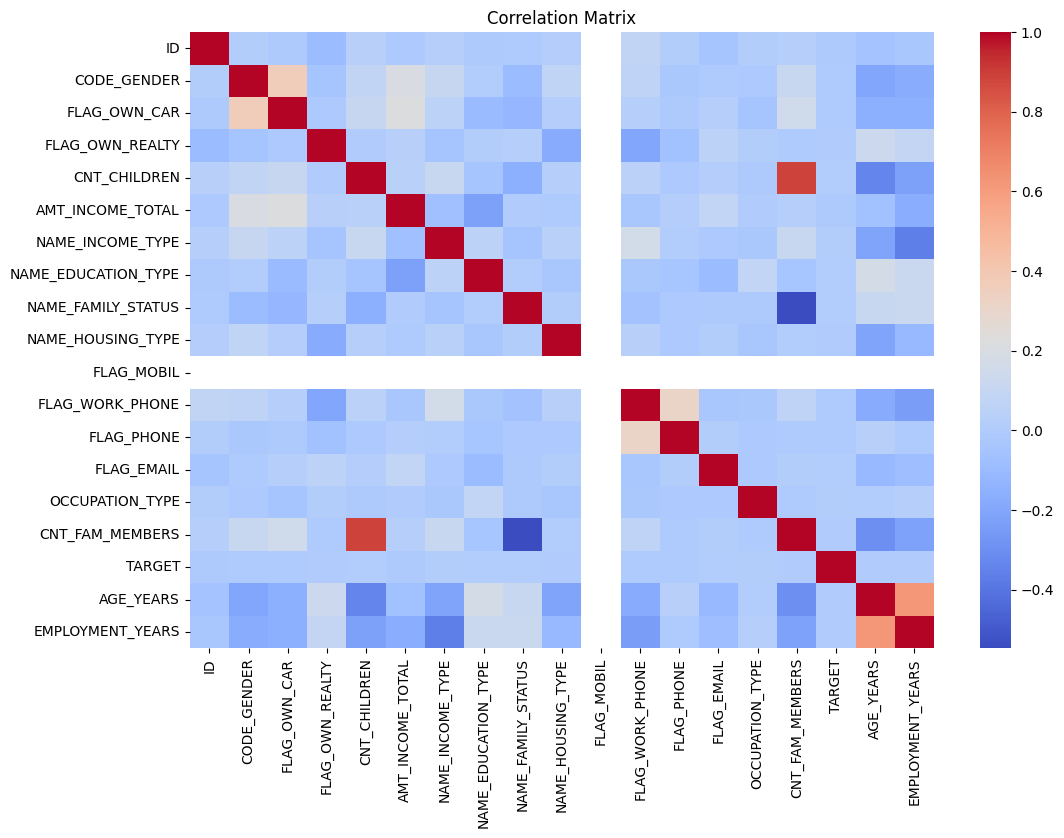

In [35]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# Step 13: Target Distribution

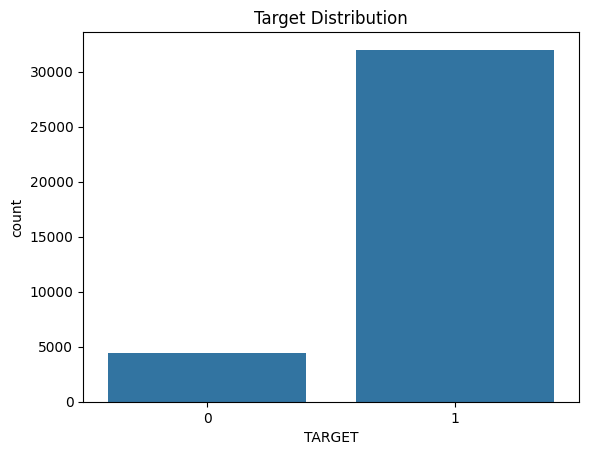

TARGET
1    32002
0     4455
Name: count, dtype: int64


In [38]:
sns.countplot(x=df["TARGET"])
plt.title("Target Distribution")
plt.show()
print(df["TARGET"].value_counts())

# Step 14: Define Features and Target

In [41]:
X = df.drop( ["ID","TARGET"], axis=1 )
y = df["TARGET"]

# Step 15: Train Test Split

In [42]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42, stratify=y )

# Step 16: Train Random Forest Model

In [44]:
model = RandomForestClassifier( n_estimators=200, random_state=42 )
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

# Step 17: Predictions

In [46]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

# Step 18: Model Evaluation

In [48]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)
print("ROC AUC :", roc_auc)

Accuracy : 0.8865880416895228
Precision : 0.9114260407440212
Recall : 0.9645367911263865
F1 Score : 0.9372296015180266
ROC AUC : 0.7681794598942961


# Step 19: Classification Report

In [61]:
print("Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Good Credit", "Bad Credit"]
    )
)

Classification Report:

              precision    recall  f1-score   support

 Good Credit       0.56      0.33      0.41       891
  Bad Credit       0.91      0.96      0.94      6401

    accuracy                           0.89      7292
   macro avg       0.74      0.65      0.68      7292
weighted avg       0.87      0.89      0.87      7292



# Step 20: Confusion Matrix

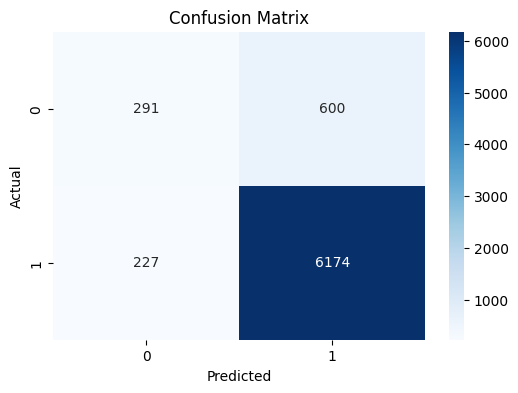

In [50]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap( cm, annot=True, fmt="d", cmap="Blues" )
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Step 21: Feature Importance

In [52]:
importance = pd.DataFrame({ "Feature": X.columns, "Importance": model.feature_importances_ })
importance = importance.sort_values( by="Importance", ascending=False )
print(importance.head(10))

                Feature  Importance
15            AGE_YEARS    0.210179
4      AMT_INCOME_TOTAL    0.208006
16     EMPLOYMENT_YEARS    0.129609
13      OCCUPATION_TYPE    0.090642
7    NAME_FAMILY_STATUS    0.045130
5      NAME_INCOME_TYPE    0.036678
14      CNT_FAM_MEMBERS    0.034206
6   NAME_EDUCATION_TYPE    0.033694
2       FLAG_OWN_REALTY    0.033303
1          FLAG_OWN_CAR    0.031428


# Step 22: Top Features Visualization

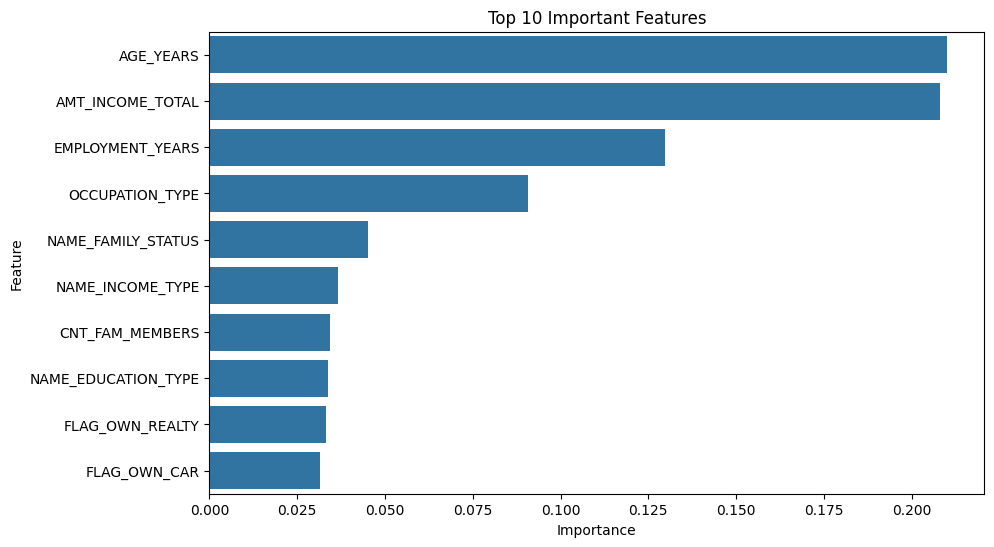

In [64]:
plt.figure(figsize=(10,6))
sns.barplot( data=importance.head(10), x="Importance", y="Feature" )
plt.title("Top 10 Important Features")
plt.show()

# Step 23: Dataset Summary

In [65]:
print("="*50)
print("DATASET SUMMARY")
print("="*50)

print("Total Records :", df.shape[0])
print("Total Features :", df.shape[1]-1)

print("\nTarget Distribution:")
print(df["TARGET"].value_counts())

DATASET SUMMARY
Total Records : 36457
Total Features : 18

Target Distribution:
TARGET
1    32002
0     4455
Name: count, dtype: int64


# Step 25: Save Model

In [67]:
import joblib
joblib.dump( model, "credit_scoring_model.pkl" )
print("Model Saved Successfully")

Model Saved Successfully


# Step 25: Final Conclusion

In [68]:
print("="*50)
print("CREDIT SCORING MODEL COMPLETED SUCCESSFULLY")
print("="*50)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC AUC   : {roc_auc:.4f}")

print("\nConclusion:")
print("The Random Forest model was trained successfully on the credit scoring dataset.")
print("The model can predict whether a customer is likely to have good or bad credit behavior.")
print("Evaluation metrics indicate the effectiveness of the model in assessing customer creditworthiness.")

CREDIT SCORING MODEL COMPLETED SUCCESSFULLY
Accuracy  : 0.8866
Precision : 0.9114
Recall    : 0.9645
F1 Score  : 0.9372
ROC AUC   : 0.7682

Conclusion:
The Random Forest model was trained successfully on the credit scoring dataset.
The model can predict whether a customer is likely to have good or bad credit behavior.
Evaluation metrics indicate the effectiveness of the model in assessing customer creditworthiness.
